- **Вопрос.** Подходит ли собранный Olist для выбранного рекомендательного baseline, и какие свойства данных нужно учесть?
- **Короткий ответ.** Для исследования признаков и воспроизводимых синтетических экспериментов — да. Реальные пользовательские истории слишком коротки для широкого персонального holdout; нужна отдельная обработка cold start. Исходный отбор остаётся ретроспективным.
- **Объект.** 96 068 позиций × 35 столбцов; 84 130 заказов, 81 541 пользователь (`customer_unique_id`), 30 991 товар. Реальные покупки 15.09.2016–29.08.2018; синтетические события здесь не создаются.
- **Порядок.** Все 13 исследовательских графиков сохранены в порядке исследования, включая проверки чувствительности и результаты без существенных изменений.


- **Входы.** `../../dataset/olist_prepared_dataset.csv` и `../../datasets/olist-eda/source_reference.csv.gz`; SHA-256 проверяется по `input_manifest.json`. [Происхождение и команды](../../datasets/olist-eda/dataset_evidence.md), [контекст](../../visualizations/olist-eda/data_context.md), [описание полей](../../feature_selection.md).
- **Reference.** По всем исходным позициям присоединены заказ, пользователь и категория; сохранены число продавцов товара и признак отбора. В notebook читается готовый результат. При его отсутствии выполнить **из корня репозитория**: `.venv/bin/python datasets/olist-eda/collect_reference.py`.
- **Правила.** Пропуски не импутируются; заказные метрики дедуплицируются по `order_id`, товарные — по `product_id`. Почтовые префиксы читаются строками. Выборок и случайных seed нет: используется полный доступный набор.
- **Параметры.** Ниже доступны `TOP_N`, `CUT_DATES`, `HOLDOUT_DAYS`. Запускать сверху вниз в окружении проекта (`uv sync --frozen`); сборка данных внутри notebook не вызывается.


In [1]:
# setup
%matplotlib inline
%config InlineBackend.figure_format = 'png'
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}
from pathlib import Path
import hashlib
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter, FuncFormatter
from IPython.display import display

pd.set_option("display.max_columns", 20)
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
DATA = ROOT / "dataset/olist_prepared_dataset.csv"
REFERENCE = ROOT / "datasets/olist-eda/source_reference.csv.gz"
FIGURES = ROOT / "visualizations/olist-eda"
EXPORT_FIGURES = False
TOP_N = 10
CUT_DATES = ["2017-10-01", "2018-01-01", "2018-04-01"]
HOLDOUT_DAYS = 90
DATES = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
         "order_delivered_customer_date", "order_estimated_delivery_date"]
KEY = ["order_id", "order_item_id"]
CARD = ["product_category_name", "product_name_lenght", "product_description_lenght",
        "product_photos_qty", "product_weight_g", "product_length_cm", "product_height_cm",
        "product_width_cm"]
NUMERIC = ["price", "freight_value", *CARD[1:]]
if not DATA.exists():
    raise FileNotFoundError("Нужен dataset/olist_prepared_dataset.csv: выполните prepare_data.ipynb.")
if not REFERENCE.exists():
    raise FileNotFoundError("Из корня: .venv/bin/python datasets/olist-eda/collect_reference.py")
manifest = json.loads((REFERENCE.parent / "input_manifest.json").read_text())
for path in [DATA, REFERENCE]:
    record = next(r for r in manifest["sources"] + manifest["outputs"] if r["path"] == str(path.relative_to(ROOT)))
    with path.open("rb") as handle:
        actual = hashlib.file_digest(handle, "sha256").hexdigest()
    assert actual == record["sha256"], f"Изменился снимок {path}; повторите collect_reference.py и исследование."
df = pd.read_csv(DATA, dtype={"customer_zip_code_prefix": "string", "seller_zip_code_prefix": "string"})
for column in DATES:
    df[column] = pd.to_datetime(df[column], errors="raise")
ref = pd.read_csv(REFERENCE, parse_dates=["order_purchase_timestamp"])
assert not df.duplicated(KEY).any() and not df[KEY].isna().any().any()
assert df.groupby("order_id")[["customer_unique_id", *DATES]].nunique(dropna=False).le(1).all().all()
assert df.groupby("product_id")[CARD].nunique(dropna=False).le(1).all().all()
assert set(pd.MultiIndex.from_frame(df[KEY])) == set(pd.MultiIndex.from_frame(ref.loc[ref.kept, KEY]))
orders = df.drop_duplicates("order_id").copy()
products = df.drop_duplicates("product_id")[["product_id", *CARD]].copy()
delivered = ref.loc[ref.order_status.eq("delivered")].copy()
source_orders = delivered.drop_duplicates("order_id")
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11,
                     "axes.titlesize": 12, "axes.labelsize": 11,
                     "figure.facecolor": "white", "axes.spines.top": False,
                     "axes.spines.right": False, "savefig.dpi": 150})
BLUE, ORANGE, GREEN, GRAY = "#2865a0", "#c76b22", "#218578", "#747d87"
plot_ids = []
findings = {}


def finish(fig, plot_id, title, caption):
    """Единый макет: подпись до трёх строк, равный размер с заголовками панелей."""
    fig.suptitle(f"{plot_id} · {title}", fontsize=15, fontweight="bold", y=.985)
    fig.text(.025, .015, caption, ha="left", va="bottom", fontsize=12)
    bottom = .16 if caption.count("\n") == 2 else .12
    fig.tight_layout(rect=(.01, bottom, .99, .93), w_pad=2.5, h_pad=2.2)
    plot_ids.append(plot_id)
    if EXPORT_FIGURES:
        fig.savefig(FIGURES / f"{plot_id}.png", facecolor="white")
        plt.close(fig)
    else:
        plt.show()


def ecdf(ax, values, label=None, color=BLUE):
    x, n = np.unique(pd.Series(values).dropna(), return_counts=True)
    y = np.cumsum(n) / n.sum() * 100
    ax.step(np.r_[x[0], x], np.r_[0, y], where="post", color=color, label=label, lw=2)
    ax.set_ylim(-2, 102)
    ax.yaxis.set_major_formatter(PercentFormatter(100))
    ax.grid(alpha=.2)


def percent_axis(ax, which="x"):
    getattr(ax, f"{which}axis").set_major_formatter(PercentFormatter(100))
    ax.grid(axis=which, alpha=.2)
    ax.set_axisbelow(True)


def short_category(value):
    return value.replace("_", " ")


schema = pd.DataFrame({"тип": df.dtypes.astype(str), "пропуски": df.isna().sum(),
                       "пропуски, %": df.isna().mean().mul(100), "уникальных": df.nunique()})
display(schema.round(3))
display(df[NUMERIC].describe(percentiles=[.01, .5, .95, .99]).T.round(2))
findings.update(rows=len(df), columns=df.shape[1], orders=len(orders), users=orders.customer_unique_id.nunique(),
                products=len(products), full_duplicates=int(df.duplicated().sum()),
                missing_any_rows=int(df.isna().any(axis=1).sum()))

,тип,пропуски,"пропуски, %",уникальных
order_id,str,0,0.000,84130
order_item_id,int64,0,0.000,21
customer_id,str,0,0.000,84130
customer_unique_id,str,0,0.000,81541
product_id,str,0,0.000,30991
price,float64,0,0.000,5390
freight_value,float64,0,0.000,6709
order_status,str,0,0.000,1
order_purchase_timestamp,datetime64[us],0,0.000,83702
order_approved_at,datetime64[us],15,0.016,77822


,count,mean,std,min,1%,50%,95%,99%,max
price,96068.0,118.91,187.77,0.85,9.90,69.90,349.90,899.00,6735.00
freight_value,96068.0,20.25,16.20,0.00,5.72,16.35,46.12,86.36,409.68
product_name_lenght,94531.0,49.31,9.89,5.00,21.00,52.00,60.00,63.00,76.00
product_description_lenght,94531.0,790.44,650.91,4.00,84.00,607.00,2098.00,3362.00,3992.00
product_photos_qty,94531.0,2.29,1.77,1.00,1.00,2.00,6.00,8.00,20.00
product_weight_g,96050.0,2170.39,3847.77,0.00,75.00,700.00,9850.00,19250.00,40425.00
product_length_cm,96050.0,30.69,16.41,7.00,16.00,25.00,63.00,98.00,105.00
product_height_cm,96050.0,16.58,13.54,2.00,2.00,13.00,45.00,65.00,105.00
product_width_cm,96050.0,23.38,11.90,6.00,11.00,20.00,45.00,63.00,118.00


- **Проверка смысла.** Уникальность ключа не исключает ошибочных дат и координат. Ниже отдельные диагностические флаги; пересекающиеся счётчики нельзя суммировать.

In [2]:
# quality
quality = []


def flag(label, mask, denominator, unit):
    quality.append({"проверка": label, "число": int(mask.sum()),
                    "знаменатель": int(denominator), "единица": unit})


for label, end, start in [
    ("Подтверждение раньше покупки", "order_approved_at", "order_purchase_timestamp"),
    ("Перевозчик раньше покупки", "order_delivered_carrier_date", "order_purchase_timestamp"),
    ("Доставка раньше покупки", "order_delivered_customer_date", "order_purchase_timestamp"),
    ("Перевозчик раньше подтверждения", "order_delivered_carrier_date", "order_approved_at"),
    ("Доставка раньше перевозчика", "order_delivered_customer_date", "order_delivered_carrier_date"),
]:
    valid = orders[[end, start]].notna().all(axis=1)
    flag(label, orders.loc[valid, end].lt(orders.loc[valid, start]), valid.sum(), "заказ")
for col in NUMERIC:
    flag(f"{col} < 0", df[col].lt(0), df[col].notna().sum(), "позиция")
for col in ["price", "freight_value", "product_weight_g", "product_photos_qty"]:
    flag(f"{col} = 0", df[col].eq(0), df[col].notna().sum(), "позиция")
for side in ["customer", "seller"]:
    lat, lon = df[f"{side}_geolocation_lat"], df[f"{side}_geolocation_lng"]
    known = lat.notna() & lon.notna()
    flag(f"{side}: вне грубой рамки Бразилии", known & ~(lat.between(-34, 6) & lon.between(-74, -34)),
         known.sum(), "позиция")
    known_state = df[f"{side}_geolocation_state"].notna()
    flag(f"{side}: несовпадение штата и геосправочника",
         known_state & df[f"{side}_state"].ne(df[f"{side}_geolocation_state"]), known_state.sum(), "позиция")
quality = pd.DataFrame(quality)
display(quality)
findings["quality_flags"] = quality.to_dict("records")
findings["missing_geo_overlap"] = int((df.customer_geolocation_lat.isna() & df.seller_geolocation_lat.isna()).sum())
findings["missing_category_products"] = int(products.product_category_name.isna().sum())
findings["varying_price_products"] = int(df.groupby("product_id").price.nunique().gt(1).sum())

,проверка,число,знаменатель,единица
0,Подтверждение раньше покупки,0,84116,заказ
1,Перевозчик раньше покупки,148,84128,заказ
2,Доставка раньше покупки,0,84124,заказ
3,Перевозчик раньше подтверждения,1193,84114,заказ
4,Доставка раньше перевозчика,23,84123,заказ
5,price < 0,0,96068,позиция
6,freight_value < 0,0,96068,позиция
7,product_name_lenght < 0,0,94531,позиция
8,product_description_lenght < 0,0,94531,позиция
9,product_photos_qty < 0,0,94531,позиция


- **Уровень товара.** Пропуски категории затрагивают 584 разных товара. Подсчёт по позициям дополнительно взвешивает проблему популярностью этих товаров.

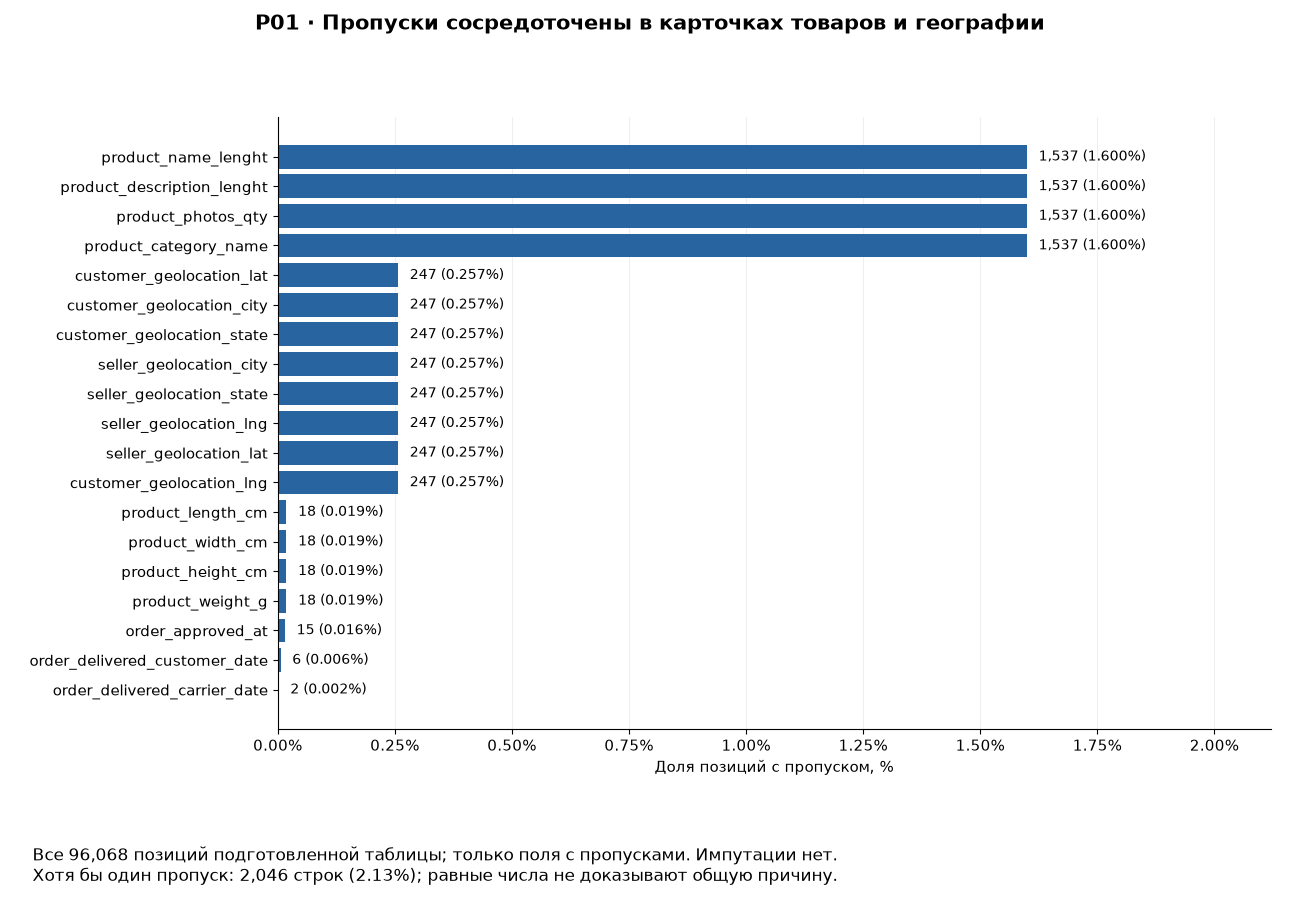

In [3]:
# P01
missing = schema.loc[schema["пропуски"].gt(0)].sort_values("пропуски")
fig, ax = plt.subplots(figsize=(13, 9))
ax.barh(missing.index, missing["пропуски, %"], color=BLUE)
for i, (_, row) in enumerate(missing.iterrows()):
    ax.text(row["пропуски, %"] + .025, i, f'{int(row["пропуски"]):,} ({row["пропуски, %"]:.3f}%)', va="center", fontsize=10)
ax.set_xlim(0, 2.12)
ax.set_xlabel("Доля позиций с пропуском, %")
percent_axis(ax)
finish(fig, "P01", "Пропуски сосредоточены в карточках товаров и географии",
       f"Все {len(df):,} позиций подготовленной таблицы; только поля с пропусками. Импутации нет.\n"
       f"Хотя бы один пропуск: {df.isna().any(axis=1).sum():,} строк ({df.isna().any(axis=1).mean():.2%}); равные числа не доказывают общую причину.")

- **Проверка отбора.** Чтобы отделить свойства источника от решений сборки, используем reference до фильтров. Его ключи `kept=True` в точности совпали с итоговым CSV.

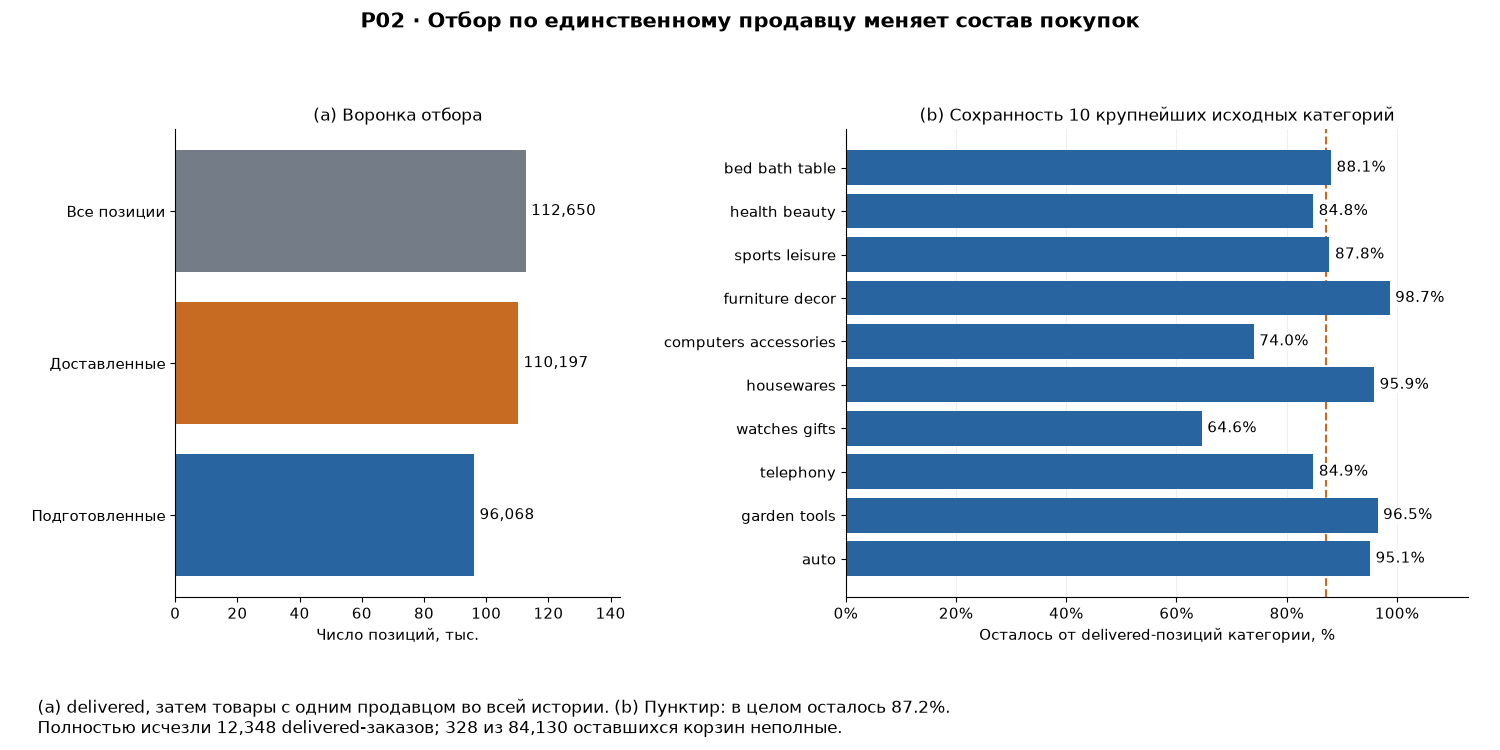

,позиции,заказы,товары
этап,,,
Исходные позиции,112650,98666,32951
Только delivered,110197,96478,32216
Подготовленная таблица,96068,84130,30991


In [4]:
# P02
stages = pd.DataFrame([
    {"этап": label, "позиции": len(frame), "заказы": frame.order_id.nunique(), "товары": frame.product_id.nunique()}
    for label, frame in [("Исходные позиции", ref), ("Только delivered", delivered), ("Подготовленная таблица", df)]
]).set_index("этап")
before_counts = delivered.groupby("order_id").size()
after_counts = df.groupby("order_id").size().reindex(before_counts.index, fill_value=0)
partial = after_counts.gt(0) & after_counts.lt(before_counts)
category_before = delivered.category.fillna("Не указано").value_counts()
category_after = df.product_category_name.fillna("Не указано").value_counts()
top_categories = category_before.head(TOP_N).index
retention = category_after.reindex(top_categories, fill_value=0).div(category_before.loc[top_categories]).mul(100)
fig, axes = plt.subplots(1, 2, figsize=(15, 7.5), gridspec_kw={"width_ratios": [1, 1.4]})
axes[0].barh(["Все позиции", "Доставленные", "Подготовленные"], stages["позиции"], color=[GRAY, ORANGE, BLUE])
axes[0].invert_yaxis()
for i, n in enumerate(stages["позиции"]):
    axes[0].text(n + 1800, i, f"{n:,}", va="center")
axes[0].set_xlim(0, len(ref) * 1.27)
axes[0].set_xlabel("Число позиций")
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x / 1000:.0f}"))
axes[0].set_xlabel("Число позиций, тыс.")
axes[0].set_title("(a) Воронка отбора")
axes[1].barh([short_category(x) for x in retention.index], retention, color=BLUE)
axes[1].invert_yaxis()
for i, value in enumerate(retention):
    axes[1].text(value + 1, i, f"{value:.1f}%", va="center", bbox={"facecolor": "white", "edgecolor": "none", "pad": .5})
axes[1].axvline(len(df) / len(delivered) * 100, color=ORANGE, ls="--", zorder=0)
axes[1].set_xlim(0, 113)
axes[1].set_xlabel("Осталось от delivered-позиций категории, %")
axes[1].set_title("(b) Сохранность 10 крупнейших исходных категорий")
percent_axis(axes[1])
finish(fig, "P02", "Отбор по единственному продавцу меняет состав покупок",
       f"(a) delivered, затем товары с одним продавцом во всей истории. (b) Пунктир: в целом осталось {len(df) / len(delivered):.1%}.\n"
       f"Полностью исчезли {after_counts.eq(0).sum():,} delivered-заказов; {partial.sum():,} из {len(orders):,} оставшихся корзин неполные.")
display(stages)
findings.update(partial_orders=int(partial.sum()), removed_orders=int(after_counts.eq(0).sum()),
                item_retention=float(len(df) / len(delivered)), category_retention=retention.to_dict())

- **Временная опора.** Перед выбором границ обучения проверяем наблюдаемое покрытие. Отсутствие строк в месяце означает отсутствие покупок в выгрузке, но не доказывает нулевую активность платформы.

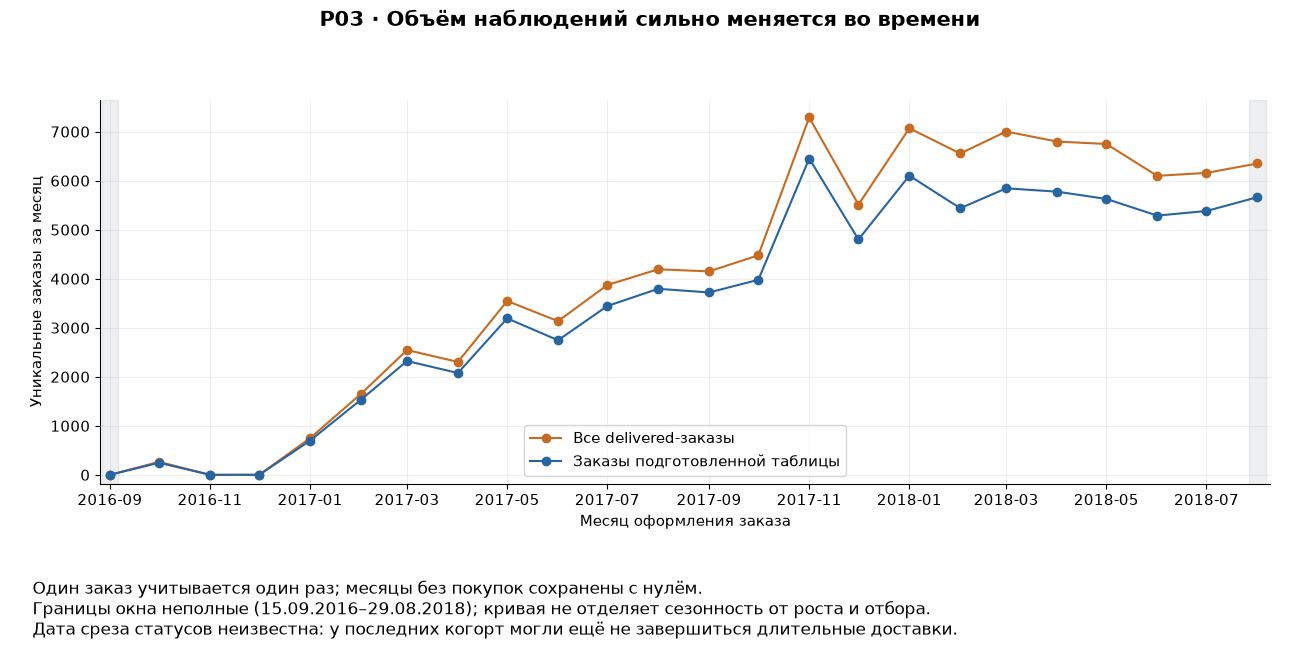

In [5]:
# P03
month_index = pd.date_range(df.order_purchase_timestamp.min().to_period("M").to_timestamp(),
                           df.order_purchase_timestamp.max().to_period("M").to_timestamp(), freq="MS")
monthly = orders.set_index("order_purchase_timestamp").resample("MS").size().reindex(month_index, fill_value=0)
monthly_before = source_orders.set_index("order_purchase_timestamp").resample("MS").size().reindex(month_index, fill_value=0)
fig, ax = plt.subplots(figsize=(13, 6.5))
ax.plot(month_index, monthly_before, color=ORANGE, marker="o", label="Все delivered-заказы")
ax.plot(month_index, monthly, color=BLUE, marker="o", label="Заказы подготовленной таблицы")
ax.set_xlabel("Месяц оформления заказа")
ax.set_ylabel("Уникальные заказы за месяц")
ax.set_ylim(bottom=-180)
ax.set_xlim(month_index[0] - pd.Timedelta(days=6), month_index[-1] + pd.Timedelta(days=8))
for boundary in [month_index[0], month_index[-1]]:
    ax.axvspan(boundary - pd.Timedelta(days=5), boundary + pd.Timedelta(days=5), color=GRAY, alpha=.12)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.legend()
ax.grid(alpha=.2)
finish(fig, "P03", "Объём наблюдений сильно меняется во времени",
       "Один заказ учитывается один раз; месяцы без покупок сохранены с нулём.\n"
       "Границы окна неполные (15.09.2016–29.08.2018); кривая не отделяет сезонность от роста и отбора.\n"
       "Дата среза статусов неизвестна: у последних когорт могли ещё не завершиться длительные доставки.")
findings["peak_month"] = str(monthly.idxmax().date())
findings["peak_month_orders"] = int(monthly.max())

- **Пространство расстояний.** Проверим масштабы перед стандартным масштабированием: редкие крупные значения могут сильно влиять на евклидовы расстояния. Наблюдаемая цена меняется внутри 4 646 товаров.

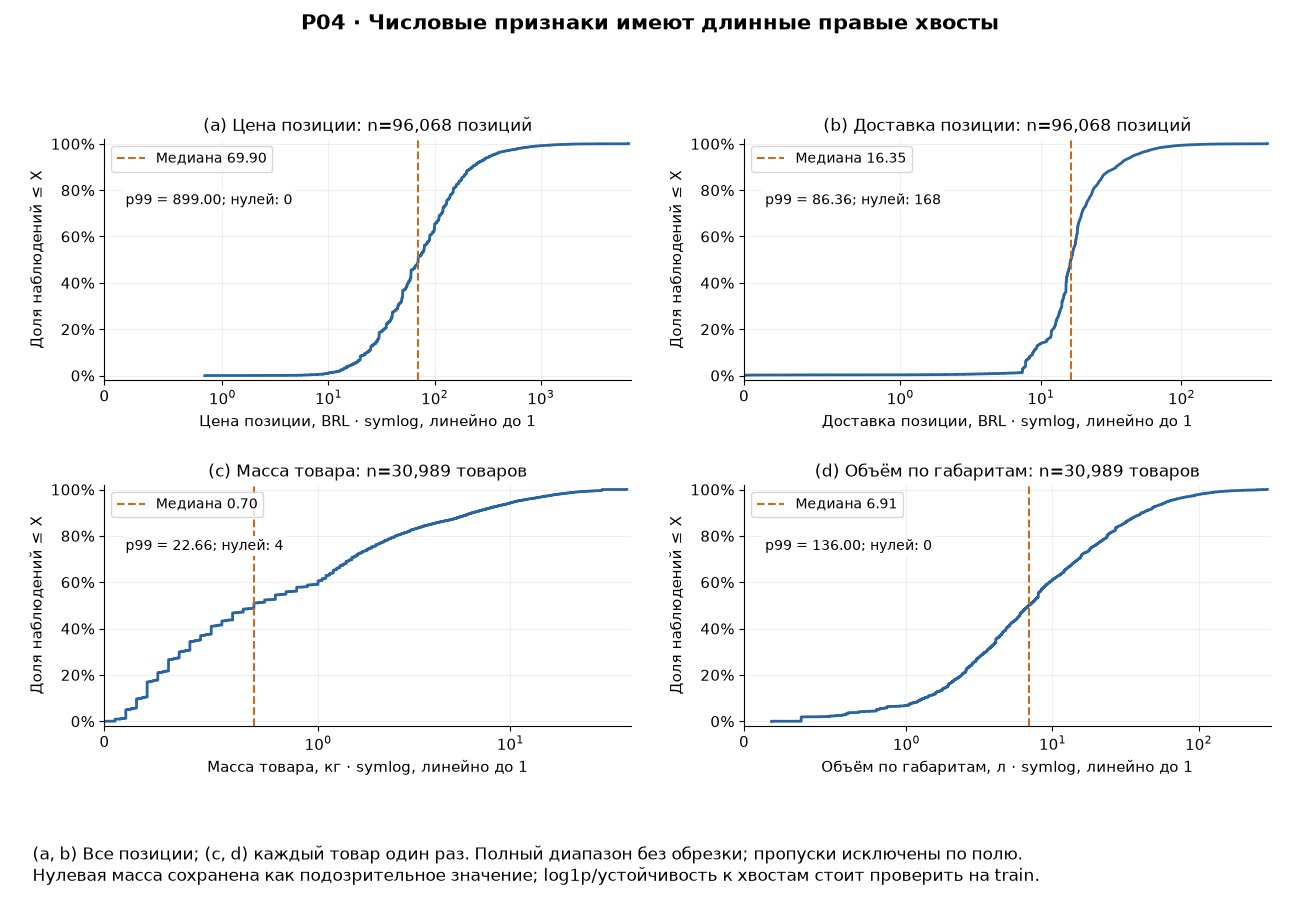

In [6]:
# P04
products["volume_l"] = products.product_length_cm * products.product_height_cm * products.product_width_cm / 1000
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, series, label, unit, panel, granularity in [
    (axes[0, 0], df.price, "Цена позиции", "BRL", "a", "позиций"),
    (axes[0, 1], df.freight_value, "Доставка позиции", "BRL", "b", "позиций"),
    (axes[1, 0], products.product_weight_g / 1000, "Масса товара", "кг", "c", "товаров"),
    (axes[1, 1], products.volume_l, "Объём по габаритам", "л", "d", "товаров"),
]:
    ecdf(ax, series)
    ax.set_xscale("symlog", linthresh=1)
    ax.set_xlim(left=0)
    q50, q99 = series.quantile([.5, .99])
    ax.axvline(q50, color=ORANGE, ls="--", label=f"Медиана {q50:.2f}")
    ax.text(.04, .73, f"p99 = {q99:.2f}; нулей: {series.eq(0).sum()}", transform=ax.transAxes, fontsize=10,
            bbox={"facecolor": "white", "edgecolor": "none", "pad": 2}, zorder=4)
    ax.set_xlabel(f"{label}, {unit} · symlog, линейно до 1")
    ax.set_ylabel("Доля наблюдений ≤ X")
    ax.set_title(f"({panel}) {label}: n={series.notna().sum():,} {granularity}")
    ax.legend(loc="upper left", fontsize=10)
finish(fig, "P04", "Числовые признаки имеют длинные правые хвосты",
       "(a, b) Все позиции; (c, d) каждый товар один раз. Полный диапазон без обрезки; пропуски исключены по полю.\n"
       "Нулевая масса сохранена как подозрительное значение; log1p/устойчивость к хвостам стоит проверить на train.")
findings["numeric_quantiles"] = df[NUMERIC].quantile([.5, .95, .99, 1]).to_dict()

- **Состав покупок.** Часть различий цен может объясняться категориями; распределение проданных позиций не является прайс-листом всего каталога.

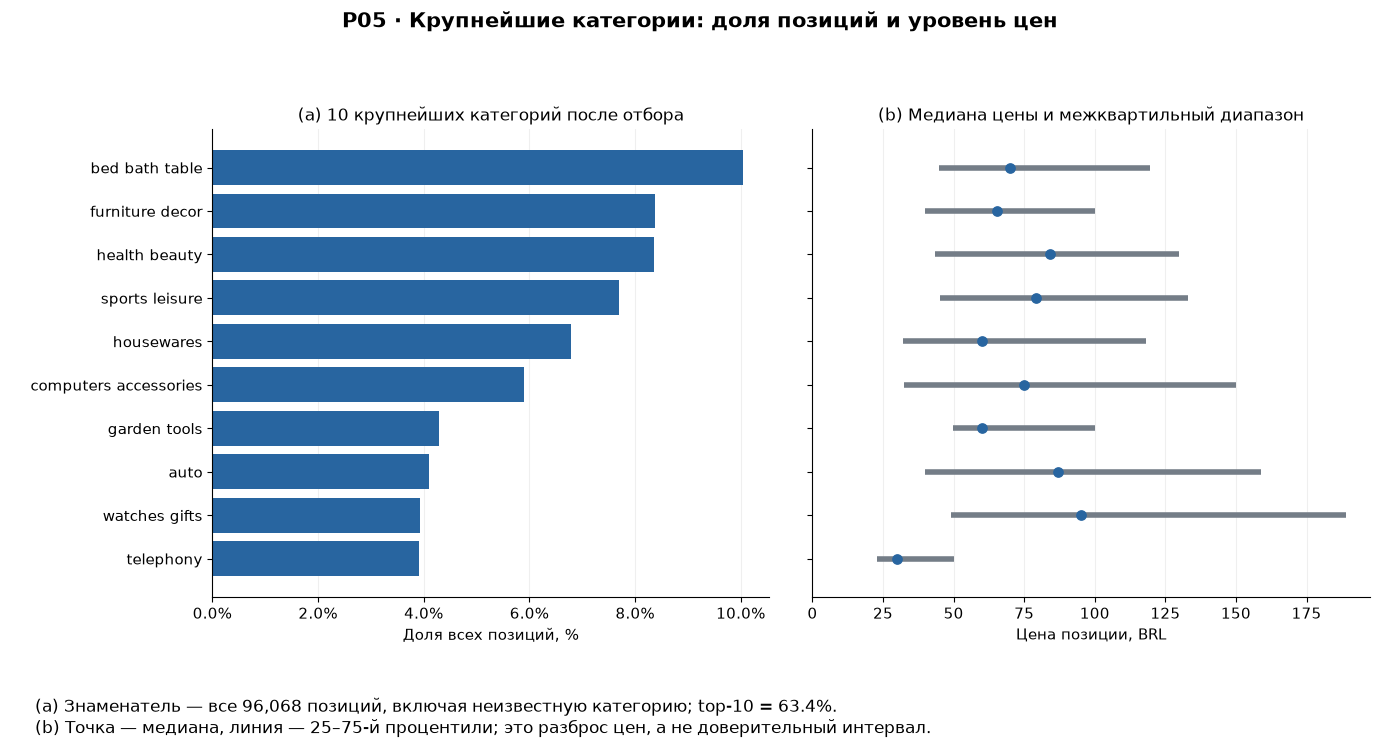

In [7]:
# P05
cat = df.product_category_name.fillna("Не указано")
counts = cat.value_counts().head(TOP_N)
q = df.assign(category=cat).groupby("category").price.quantile([.25, .5, .75]).unstack().loc[counts.index]
fig, axes = plt.subplots(1, 2, figsize=(14, 7.5), sharey=True)
y = np.arange(len(counts))
axes[0].barh(y, counts / len(df) * 100, color=BLUE)
axes[0].set_yticks(y, [short_category(c) for c in counts.index])
axes[0].invert_yaxis()
axes[0].set_xlabel("Доля всех позиций, %")
axes[0].set_title("(a) 10 крупнейших категорий после отбора")
percent_axis(axes[0])
axes[1].hlines(y, q[.25], q[.75], color=GRAY, linewidth=4)
axes[1].scatter(q[.5], y, color=BLUE, s=45, zorder=3)
axes[1].set_xlabel("Цена позиции, BRL")
axes[1].set_xlim(left=0)
axes[1].set_title("(b) Медиана цены и межквартильный диапазон")
axes[1].grid(axis="x", alpha=.2)
finish(fig, "P05", "Крупнейшие категории: доля позиций и уровень цен",
       f"(a) Знаменатель — все {len(df):,} позиций, включая неизвестную категорию; top-10 = {counts.sum() / len(df):.1%}.\n"
       "(b) Точка — медиана, линия — 25–75-й процентили; это разброс цен, а не доверительный интервал.")
findings["top10_categories_share"] = float(counts.sum() / len(df))

- **Географический контекст.** Город без штата может объединять разные места. Здесь используются устойчивее интерпретируемые адресные коды штатов, без нормировки на население.

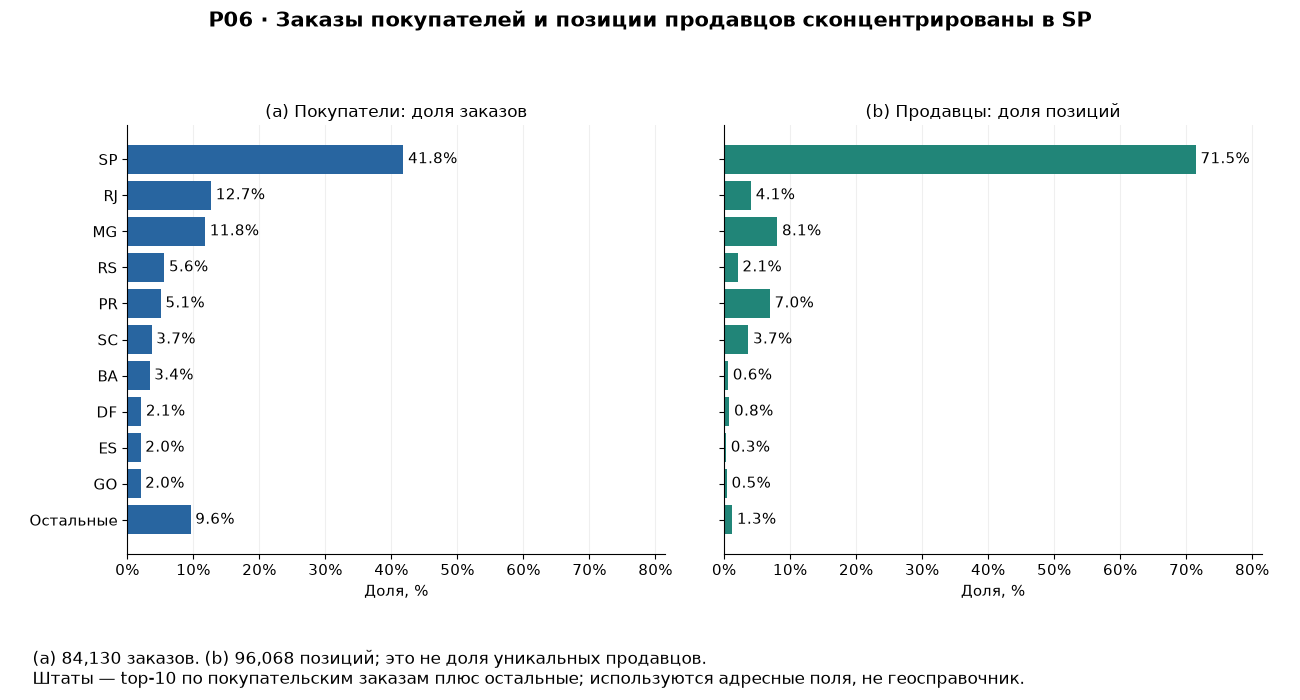

In [8]:
# P06
buyer_states = orders.customer_state.value_counts(normalize=True).mul(100)
seller_states = df.seller_state.value_counts(normalize=True).mul(100)
states = buyer_states.head(TOP_N).index
buyer_plot = pd.concat([buyer_states.reindex(states), pd.Series({"Остальные": 100 - buyer_states.reindex(states).sum()})])
seller_plot = pd.concat([seller_states.reindex(states, fill_value=0),
                         pd.Series({"Остальные": 100 - seller_states.reindex(states, fill_value=0).sum()})])
fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True, sharex=True)
for ax, values, title, color in [(axes[0], buyer_plot, "(a) Покупатели: доля заказов", BLUE),
                                (axes[1], seller_plot, "(b) Продавцы: доля позиций", GREEN)]:
    ax.barh(values.index, values, color=color)
    for i, value in enumerate(values):
        ax.text(value + .7, i, f"{value:.1f}%", va="center")
    ax.set_xlim(0, max(buyer_plot.max(), seller_plot.max()) + 10)
    ax.set_title(title)
    ax.set_xlabel("Доля, %")
    percent_axis(ax)
axes[0].invert_yaxis()
finish(fig, "P06", "Заказы покупателей и позиции продавцов сконцентрированы в SP",
       f"(a) {len(orders):,} заказов. (b) {len(df):,} позиций; это не доля уникальных продавцов.\n"
       "Штаты — top-10 по покупательским заказам плюс остальные; используются адресные поля, не геосправочник.")
findings.update(buyer_sp_share=float(buyer_states["SP"] / 100), seller_sp_share=float(seller_states["SP"] / 100))

- **История пользователя.** `customer_id` относится к записи заказа; объединять реальные истории нужно через `customer_unique_id`. Ни размер корзины, ни повторные единицы товара не заменяют отдельные заказы.

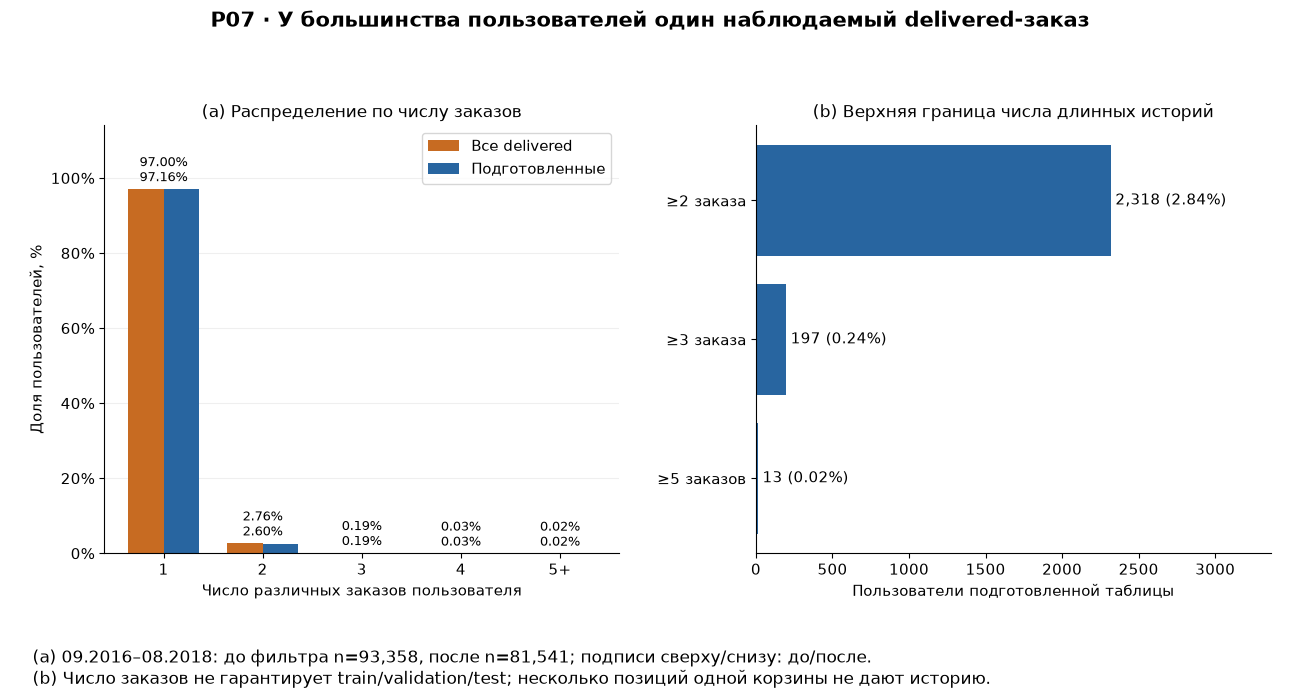

,Все delivered,Подготовленные
order_id,,
1,90557,79223
2,2573,2121
3,181,157
4,28,27
5,19,13


In [9]:
# P07
histories = orders.groupby("customer_unique_id").order_id.nunique()
before_histories = source_orders.groupby("customer_unique_id").order_id.nunique()
labels = ["1", "2", "3", "4", "5+"]
history_table = pd.DataFrame({
    "Все delivered": before_histories.clip(upper=5).value_counts().reindex(range(1, 6), fill_value=0),
    "Подготовленные": histories.clip(upper=5).value_counts().reindex(range(1, 6), fill_value=0),
})
fig, axes = plt.subplots(1, 2, figsize=(13, 7))
for column, offset, color in [("Все delivered", -.18, ORANGE), ("Подготовленные", .18, BLUE)]:
    shares = history_table[column] / history_table[column].sum() * 100
    axes[0].bar(np.arange(5) + offset, shares, width=.36, label=column, color=color)
axes[0].set_xticks(range(5), labels)
axes[0].set_ylabel("Доля пользователей, %")
axes[0].set_xlabel("Число различных заказов пользователя")
axes[0].set_title("(a) Распределение по числу заказов")
for i in range(5):
    before_share = history_table["Все delivered"].iloc[i] / len(before_histories) * 100
    after_share = history_table["Подготовленные"].iloc[i] / len(histories) * 100
    axes[0].text(i, max(before_share, after_share) + 2, f"{before_share:.2f}%\n{after_share:.2f}%",
                 ha="center", fontsize=9)
axes[0].set_ylim(0, 114)
axes[0].legend()
percent_axis(axes[0], "y")
eligible = pd.Series({"≥2 заказа": histories.ge(2).sum(), "≥3 заказа": histories.ge(3).sum(),
                      "≥5 заказов": histories.ge(5).sum()})
axes[1].barh(eligible.index, eligible, color=BLUE)
axes[1].invert_yaxis()
for i, value in enumerate(eligible):
    axes[1].text(value + 30, i, f"{value:,} ({value / len(histories):.2%})", va="center")
axes[1].set_xlim(0, eligible.max() * 1.45)
axes[1].set_xlabel("Пользователи подготовленной таблицы")
axes[1].set_title("(b) Верхняя граница числа длинных историй")
finish(fig, "P07", "У большинства пользователей один наблюдаемый delivered-заказ",
       f"(a) 09.2016–08.2018: до фильтра n={len(before_histories):,}, после n={len(histories):,}; подписи сверху/снизу: до/после.\n"
       "(b) Число заказов не гарантирует train/validation/test; несколько позиций одной корзины не дают историю.")
display(history_table)
user_product_orders = df.groupby(["customer_unique_id", "product_id"]).order_id.nunique()
findings.update(single_order_share=float(histories.eq(1).mean()), repeat_users=int(histories.ge(2).sum()),
                three_order_users=int(histories.ge(3).sum()), before_repeat_share=float(before_histories.ge(2).mean()),
                repeat_user_product_pairs=int(user_product_orders.ge(2).sum()),
                unique_user_product_pairs=len(user_product_orders),
                matrix_density=float(len(user_product_orders) / (len(histories) * len(products))))

- **История товара.** Плотность наблюдаемой матрицы user–item — 0,003442%: 86 973 уникальные пары. В разных заказах повторяются только 327 пар. Время присутствия товара и экспозиции неизвестны.

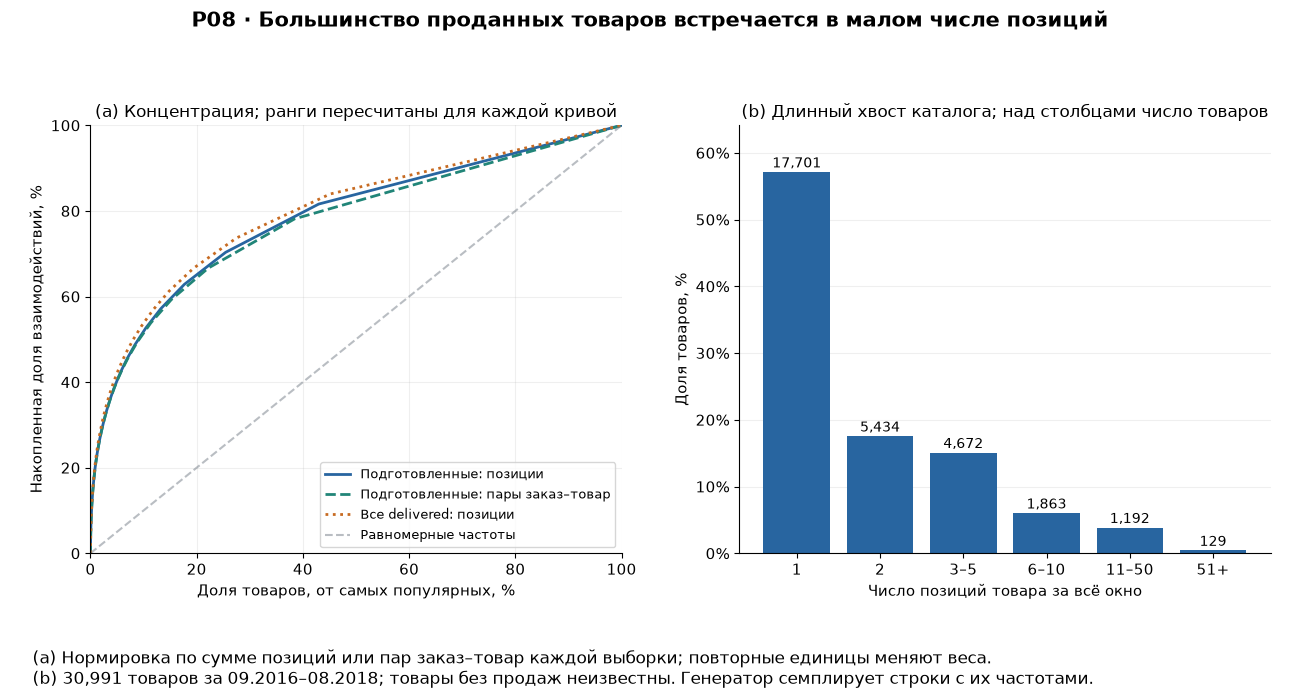

In [10]:
# P08
popularity = df.product_id.value_counts()
unique_order_pop = df.groupby("product_id").order_id.nunique().sort_values(ascending=False)
source_pop = delivered.product_id.value_counts()
fig, axes = plt.subplots(1, 2, figsize=(13, 7))
for series, label, color, style in [(popularity, "Подготовленные: позиции", BLUE, "-"),
                                    (unique_order_pop, "Подготовленные: пары заказ–товар", GREEN, "--"),
                                    (source_pop, "Все delivered: позиции", ORANGE, ":")]:
    x = np.arange(1, len(series) + 1) / len(series) * 100
    axes[0].plot(np.r_[0, x], np.r_[0, series.cumsum() / series.sum() * 100], label=label, color=color, ls=style, lw=2)
axes[0].plot([0, 100], [0, 100], color=GRAY, ls="--", alpha=.5, label="Равномерные частоты")
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 100)
axes[0].set_xlabel("Доля товаров, от самых популярных, %")
axes[0].set_ylabel("Накопленная доля взаимодействий, %")
axes[0].set_title("(a) Концентрация; ранги пересчитаны для каждой кривой")
axes[0].legend(fontsize=9, loc="lower right")
axes[0].grid(alpha=.2)
freq_labels = ["1", "2", "3–5", "6–10", "11–50", "51+"]
freq = pd.cut(popularity, [0, 1, 2, 5, 10, 50, np.inf], labels=freq_labels).value_counts(sort=False)
axes[1].bar(freq.index.astype(str), freq / len(popularity) * 100, color=BLUE)
for i, value in enumerate(freq):
    axes[1].text(i, value / len(popularity) * 100 + .7, f"{value:,}", ha="center", fontsize=10)
axes[1].set_ylim(0, (freq / len(popularity) * 100).max() + 7)
axes[1].set_xlabel("Число позиций товара за всё окно")
axes[1].set_ylabel("Доля товаров, %")
axes[1].set_title("(b) Длинный хвост каталога; над столбцами число товаров")
percent_axis(axes[1], "y")
finish(fig, "P08", "Большинство проданных товаров встречается в малом числе позиций",
       "(a) Нормировка по сумме позиций или пар заказ–товар каждой выборки; повторные единицы меняют веса.\n"
       f"(b) {len(popularity):,} товаров за 09.2016–08.2018; товары без продаж неизвестны. Генератор семплирует строки с их частотами.")
findings.update(singleton_products=int(popularity.eq(1).sum()), singleton_product_share=float(popularity.eq(1).mean()),
                top1pct_item_share=float(popularity.iloc[:math.ceil(len(popularity) * .01)].sum() / len(df)),
                top10pct_item_share=float(popularity.iloc[:math.ceil(len(popularity) * .1)].sum() / len(df)))

- **Практическое следствие.** Большое общее число пользователей не означает большой набор персональных тестовых историй. Проверяем три независимых временных окна; это аудит покрытия до моделирования.

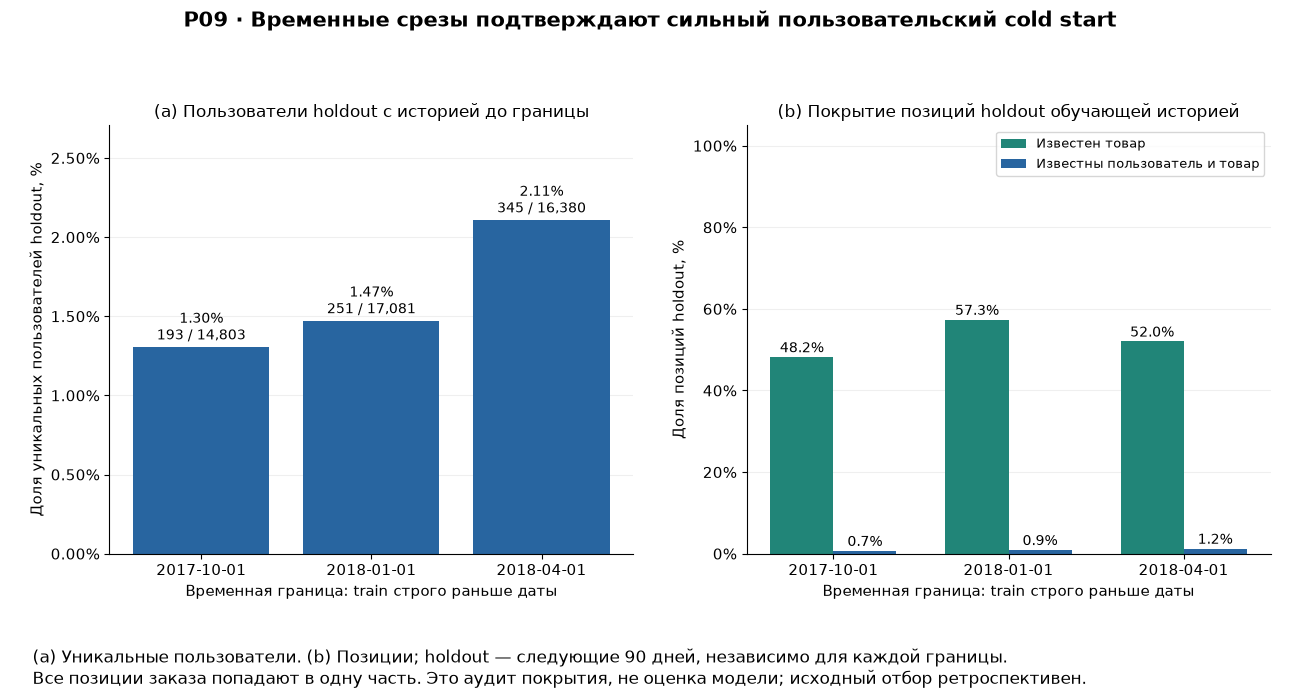

,cut,end_exclusive,train_orders,test_orders,test_items,test_users,known_users,known_users_pct,known_product_items_pct,both_known_items_pct,unseen_unique_products_pct
0,2017-10-01,2017-12-30,23776,15087,17373,14803,193,1.303790,48.183964,0.696483,69.961637
1,2018-01-01,2018-04-01,39007,17386,19801,17081,251,1.469469,57.340538,0.909045,62.202453
2,2018-04-01,2018-06-30,56393,16583,19176,16380,345,2.106227,52.018148,1.241135,63.408550


In [11]:
# P09
cold_rows = []
for cut_string in CUT_DATES:
    cut = pd.Timestamp(cut_string)
    end = cut + pd.Timedelta(days=HOLDOUT_DAYS)
    train = df.loc[df.order_purchase_timestamp.lt(cut)]
    test = df.loc[df.order_purchase_timestamp.ge(cut) & df.order_purchase_timestamp.lt(end)]
    test_orders = test.drop_duplicates("order_id")
    known_users = test.customer_unique_id.isin(train.customer_unique_id)
    known_products = test.product_id.isin(train.product_id)
    test_users = test.customer_unique_id.drop_duplicates()
    cold_rows.append({
        "cut": cut, "end_exclusive": end, "train_orders": train.order_id.nunique(),
        "test_orders": len(test_orders), "test_items": len(test), "test_users": len(test_users),
        "known_users": int(test_users.isin(train.customer_unique_id).sum()),
        "known_users_pct": test_users.isin(train.customer_unique_id).mean() * 100,
        "known_product_items_pct": known_products.mean() * 100,
        "both_known_items_pct": (known_users & known_products).mean() * 100,
        "unseen_unique_products_pct": (~test.product_id.drop_duplicates().isin(train.product_id)).mean() * 100,
    })
cold = pd.DataFrame(cold_rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 7))
x = np.arange(len(cold))
axes[0].bar(x, cold.known_users_pct, color=BLUE)
for i, row in cold.iterrows():
    axes[0].text(i, row.known_users_pct + .05, f"{row.known_users_pct:.2f}%\n{row.known_users:,} / {row.test_users:,}", ha="center", fontsize=10)
axes[0].set_ylim(0, cold.known_users_pct.max() + .6)
axes[0].set_title("(a) Пользователи holdout с историей до границы")
axes[0].set_ylabel("Доля уникальных пользователей holdout, %")
for col, offset, color, label in [("known_product_items_pct", -.18, GREEN, "Известен товар"),
                                 ("both_known_items_pct", .18, BLUE, "Известны пользователь и товар")]:
    axes[1].bar(x + offset, cold[col], width=.36, color=color, label=label)
    for i, value in enumerate(cold[col]):
        axes[1].text(i + offset, value + 1.2, f"{value:.1f}%", ha="center", fontsize=10)
axes[1].set_ylim(0, 105)
axes[1].set_title("(b) Покрытие позиций holdout обучающей историей")
axes[1].set_ylabel("Доля позиций holdout, %")
axes[1].legend(loc="upper right", fontsize=9)
for ax in axes:
    ax.set_xticks(x, [d.strftime("%Y-%m-%d") for d in cold.cut])
    ax.set_xlabel("Временная граница: train строго раньше даты")
    percent_axis(ax, "y")
finish(fig, "P09", "Временные срезы подтверждают сильный пользовательский cold start",
       f"(a) Уникальные пользователи. (b) Позиции; holdout — следующие {HOLDOUT_DAYS} дней, независимо для каждой границы.\n"
       "Все позиции заказа попадают в одну часть. Это аудит покрытия, не оценка модели; исходный отбор ретроспективен.")
display(cold)
first_purchase = orders.groupby("customer_unique_id").order_purchase_timestamp.min()
eligible_first = first_purchase.loc[first_purchase.le(orders.order_purchase_timestamp.max() - pd.Timedelta(days=90))]
early = orders.loc[orders.customer_unique_id.isin(eligible_first.index)].copy()
early["first"] = early.customer_unique_id.map(eligible_first)
within90 = early.loc[early.order_purchase_timestamp.le(early["first"] + pd.Timedelta(days=90))]
repeat90 = within90.groupby("customer_unique_id").order_id.nunique().ge(2)
findings["cold_start"] = cold.assign(cut=cold.cut.astype(str), end_exclusive=cold.end_exclusive.astype(str)).to_dict("records")
findings.update(users_with_90d_followup=len(repeat90), repeat_within90_share=float(repeat90.mean()))

- **Зависимость признаков.** Сопоставляем вес каждой проданной позиции с весом каждого товара. Спирмен отражает монотонность, а не причинность; парные `n` не являются числом независимых наблюдений.

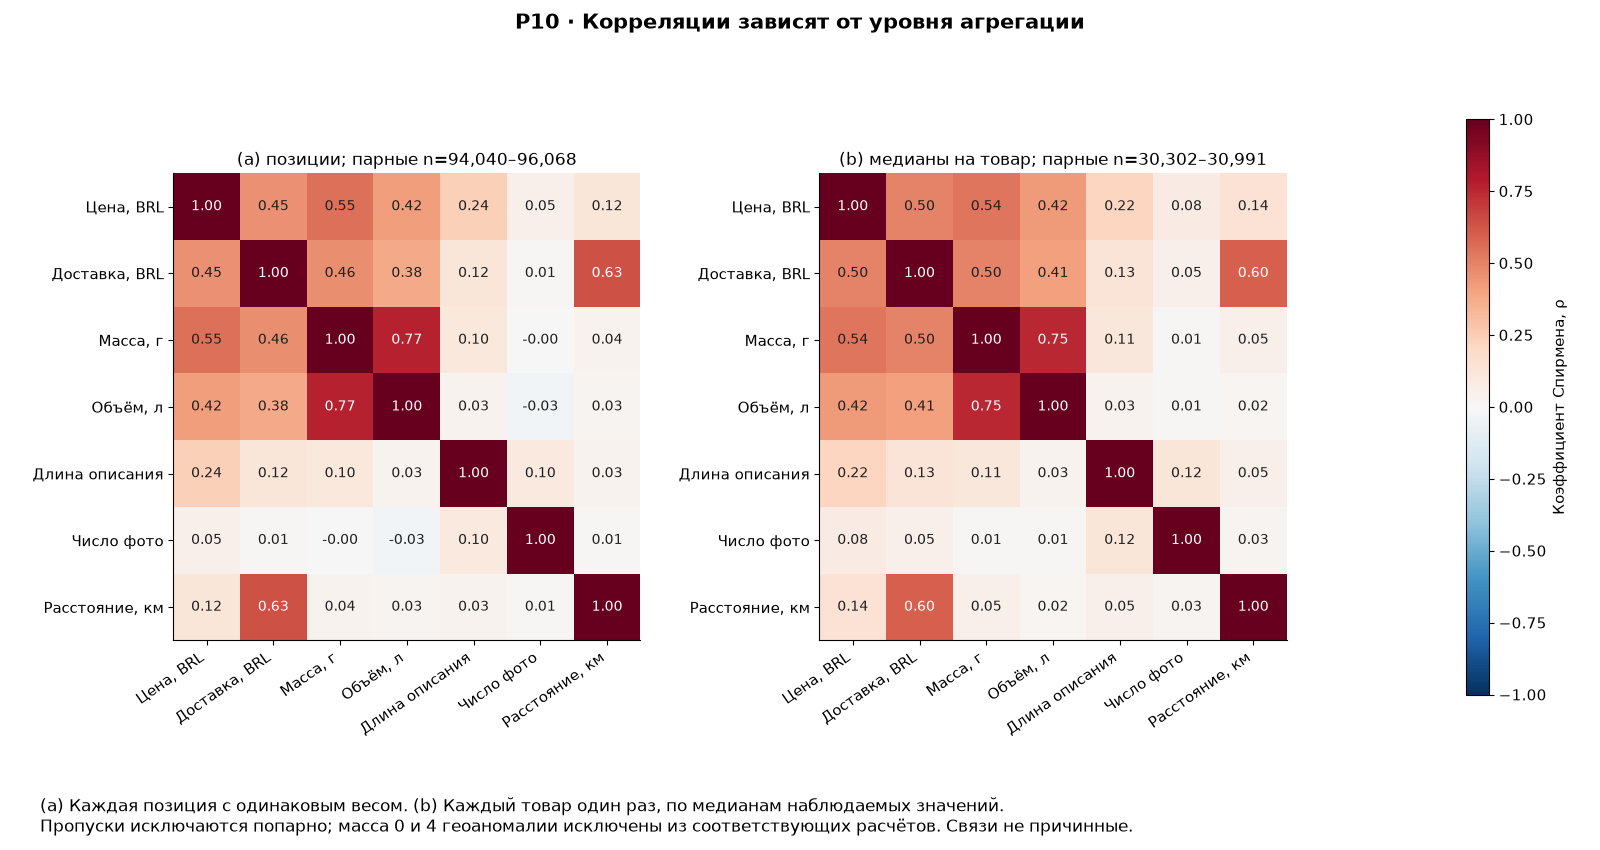

In [12]:
# P10
geo_cols = [f"{side}_geolocation_{coord}" for side in ["customer", "seller"] for coord in ["lat", "lng"]]
geo_known = df[geo_cols].notna().all(axis=1)
geo_valid = geo_known.copy()
for side in ["customer", "seller"]:
    geo_valid &= df[f"{side}_geolocation_lat"].between(-34, 6) & df[f"{side}_geolocation_lng"].between(-74, -34)
lat1, lon1, lat2, lon2 = [np.deg2rad(df[c]) for c in geo_cols]
h = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
df["distance_km"] = (6371.0088 * 2 * np.arcsin(np.sqrt(h.clip(0, 1)))).where(geo_valid)
df["volume_l"] = df.product_length_cm * df.product_height_cm * df.product_width_cm / 1000
feature_labels = {"price": "Цена, BRL", "freight_value": "Доставка, BRL", "product_weight_g": "Масса, г",
                  "volume_l": "Объём, л", "product_description_lenght": "Длина описания",
                  "product_photos_qty": "Число фото", "distance_km": "Расстояние, км"}
cols = list(feature_labels)
# Нулевой вес сохраняется в профиле качества, но не считается физической массой.
numeric = df[cols].copy()
numeric.loc[numeric.product_weight_g.le(0), "product_weight_g"] = np.nan
by_product = numeric.groupby(df.product_id).median()
fig, axes = plt.subplots(1, 3, figsize=(16, 8.5), gridspec_kw={"width_ratios": [1, 1, .05]})
correlations = []
for ax, frame, panel, label in [(axes[0], numeric, "a", "позиции"), (axes[1], by_product, "b", "медианы на товар")]:
    corr = frame.corr(method="spearman")
    valid_counts = frame.notna().astype(int).T.dot(frame.notna().astype(int))
    correlations.append(corr)
    image = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(cols)), list(feature_labels.values()), rotation=35, ha="right")
    ax.set_yticks(range(len(cols)), list(feature_labels.values()))
    for i in range(len(cols)):
        for j in range(len(cols)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=10,
                    color="white" if abs(corr.iloc[i, j]) > .55 else "#202020")
    ax.set_title(f"({panel}) {label}; парные n={valid_counts.min().min():,}–{valid_counts.max().max():,}")
fig.colorbar(image, cax=axes[2], label="Коэффициент Спирмена, ρ")
finish(fig, "P10", "Корреляции зависят от уровня агрегации",
       "(a) Каждая позиция с одинаковым весом. (b) Каждый товар один раз, по медианам наблюдаемых значений.\n"
       "Пропуски исключаются попарно; масса 0 и 4 геоаномалии исключены из соответствующих расчётов. Связи не причинные.")
findings["spearman_items"] = correlations[0].round(4).to_dict()
findings["spearman_products"] = correlations[1].round(4).to_dict()
findings.update(geo_missing_rows=int((~geo_known).sum()), geo_outside_rows=int((geo_known & ~geo_valid).sum()),
                distance_median_km=float(df.distance_km.median()))

- **Проверка объяснения.** Общая связь расстояния и доставки может быть связана с массой. Проверим группы массы, а затем хвосты, повторные единицы и одну категорию.

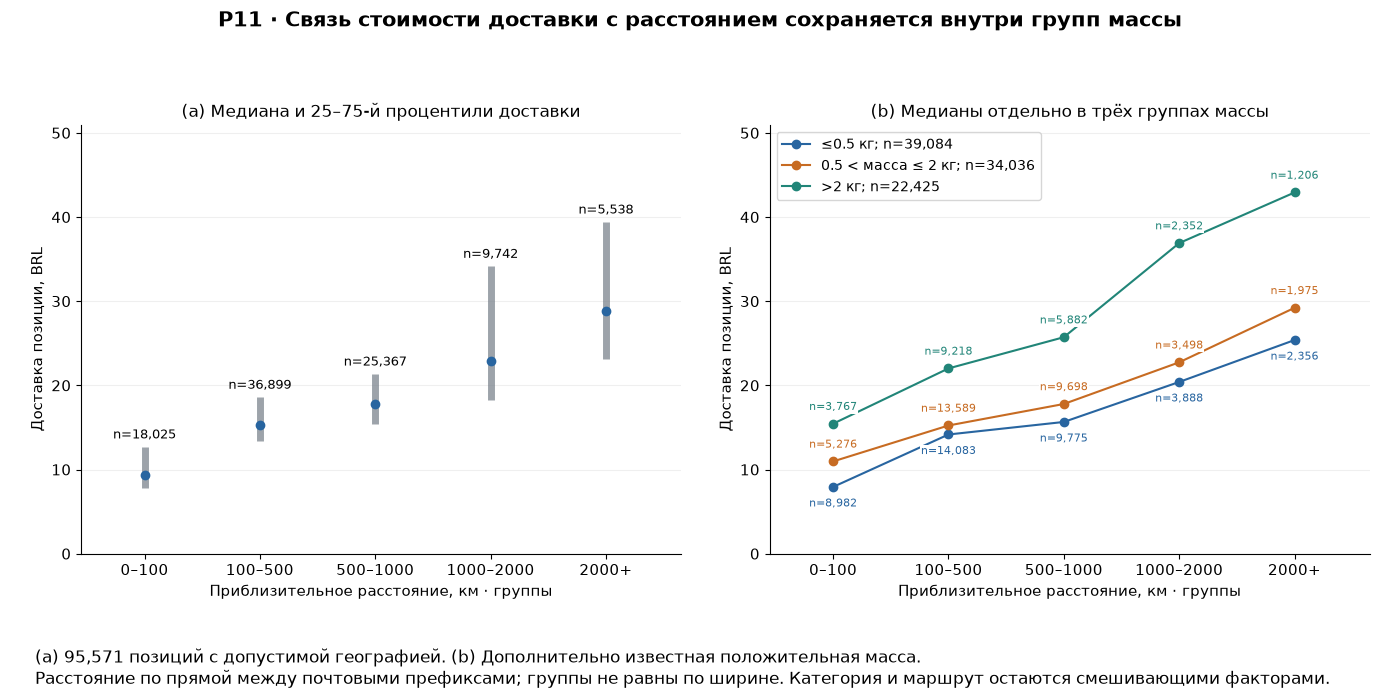

median   size
distance_bin weight_bin                       
0–100        ≤0.5 кг              7.930   8982
             0.5 < масса ≤ 2 кг  10.960   5276
             >2 кг               15.440   3767
100–500      ≤0.5 кг             14.160  14083
             0.5 < масса ≤ 2 кг  15.230  13589
             >2 кг               22.010   9218
500–1000     ≤0.5 кг             15.650   9775
             0.5 < масса ≤ 2 кг  17.785   9698
             >2 кг               25.720   5882
1000–2000    ≤0.5 кг             20.400   3888
             0.5 < масса ≤ 2 кг  22.735   3498
             >2 кг               36.900   2352
2000+        ≤0.5 кг             25.380   2356
             0.5 < масса ≤ 2 кг  29.210   1975
             >2 кг               42.915   1206

,выборка,n,rho_distance_freight
0,Все допустимые позиции,95571,0.633
1,Без верхнего 1% доставки/расстояния,93710,0.627
2,Пары заказ–товар,86858,0.637
3,Только health_beauty,8007,0.783


In [13]:
# P11
distance_labels = ["0–100", "100–500", "500–1000", "1000–2000", "2000+"]
df["distance_bin"] = pd.cut(df.distance_km, [-.001, 100, 500, 1000, 2000, np.inf], labels=distance_labels)
df["weight_bin"] = pd.cut(df.product_weight_g.where(df.product_weight_g.gt(0)),
                          [0, 500, 2000, np.inf], labels=["≤0.5 кг", "0.5 < масса ≤ 2 кг", ">2 кг"])
valid_freight = df.loc[df.distance_bin.notna()]
freight_q = valid_freight.groupby("distance_bin", observed=False).freight_value.quantile([.25, .5, .75]).unstack()
freight_n = valid_freight.groupby("distance_bin", observed=False).size()
strata = valid_freight.groupby(["distance_bin", "weight_bin"], observed=False).freight_value.agg(["median", "size"])
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
x = np.arange(len(distance_labels))
axes[0].vlines(x, freight_q[.25], freight_q[.75], color=GRAY, lw=5, alpha=.7)
axes[0].scatter(x, freight_q[.5], color=BLUE, zorder=3)
for i, n in enumerate(freight_n):
    axes[0].text(i, freight_q[.75].iloc[i] + 1, f"n={n:,}", ha="center", fontsize=9)
axes[0].set_title("(a) Медиана и 25–75-й процентили доставки")
for weight, color in zip(df.weight_bin.cat.categories, [BLUE, ORANGE, GREEN]):
    group = strata.xs(weight, level="weight_bin").reindex(distance_labels)
    axes[1].plot(x, group["median"], marker="o", color=color, label=f"{weight}; n={group['size'].sum():,}")
    for i, row in enumerate(group.itertuples()):
        below = color == BLUE
        axes[1].annotate(f"n={row.size:,}", (i, row.median), xytext=(0, -8 if below else 8), textcoords="offset points",
                         ha="center", va="top" if below else "bottom", color=color, fontsize=8,
                         bbox={"facecolor": "white", "edgecolor": "none", "pad": .7}, zorder=4)
axes[1].set_title("(b) Медианы отдельно в трёх группах массы")
axes[1].legend(fontsize=10)
for ax in axes:
    ax.set_xticks(x, distance_labels)
    ax.set_xlim(-.55, 4.65)
    ax.set_xlabel("Приблизительное расстояние, км · группы")
    ax.set_ylabel("Доставка позиции, BRL")
    ax.set_ylim(0, max(freight_q[.75].max(), strata["median"].max()) + 8)
    ax.grid(axis="y", alpha=.2)
finish(fig, "P11", "Связь стоимости доставки с расстоянием сохраняется внутри групп массы",
       f"(a) {len(valid_freight):,} позиций с допустимой географией. (b) Дополнительно известная положительная масса.\n"
       "Расстояние по прямой между почтовыми префиксами; группы не равны по ширине. Категория и маршрут остаются смешивающими факторами.")
display(strata)
# Чувствительность корреляции: хвосты, повторные позиции, неполные поля и отдельная категория.
joint = df.loc[df.distance_km.notna()].copy()
trim = joint.loc[joint.freight_value.le(joint.freight_value.quantile(.99)) & joint.distance_km.le(joint.distance_km.quantile(.99))]
checks = []
for label, frame in [("Все допустимые позиции", joint), ("Без верхнего 1% доставки/расстояния", trim),
                     ("Пары заказ–товар", joint.drop_duplicates(["order_id", "product_id"])),
                     ("Только health_beauty", joint.loc[joint.product_category_name.eq("health_beauty")])]:
    checks.append({"выборка": label, "n": len(frame),
                   "rho_distance_freight": frame[["distance_km", "freight_value"]].corr(method="spearman").iloc[0, 1]})
sensitivity = pd.DataFrame(checks)
display(sensitivity.round(3))
findings["freight_sensitivity"] = sensitivity.to_dict("records")

- **Отдельная ретроспективная задача.** Стоимость доставки и её срок — разные величины. Опоздание ниже определяется календарной датой позже обещанной: доставка в обещанный день не считается поздней. Исключение по согласованности требует также полноты всех пяти дат.

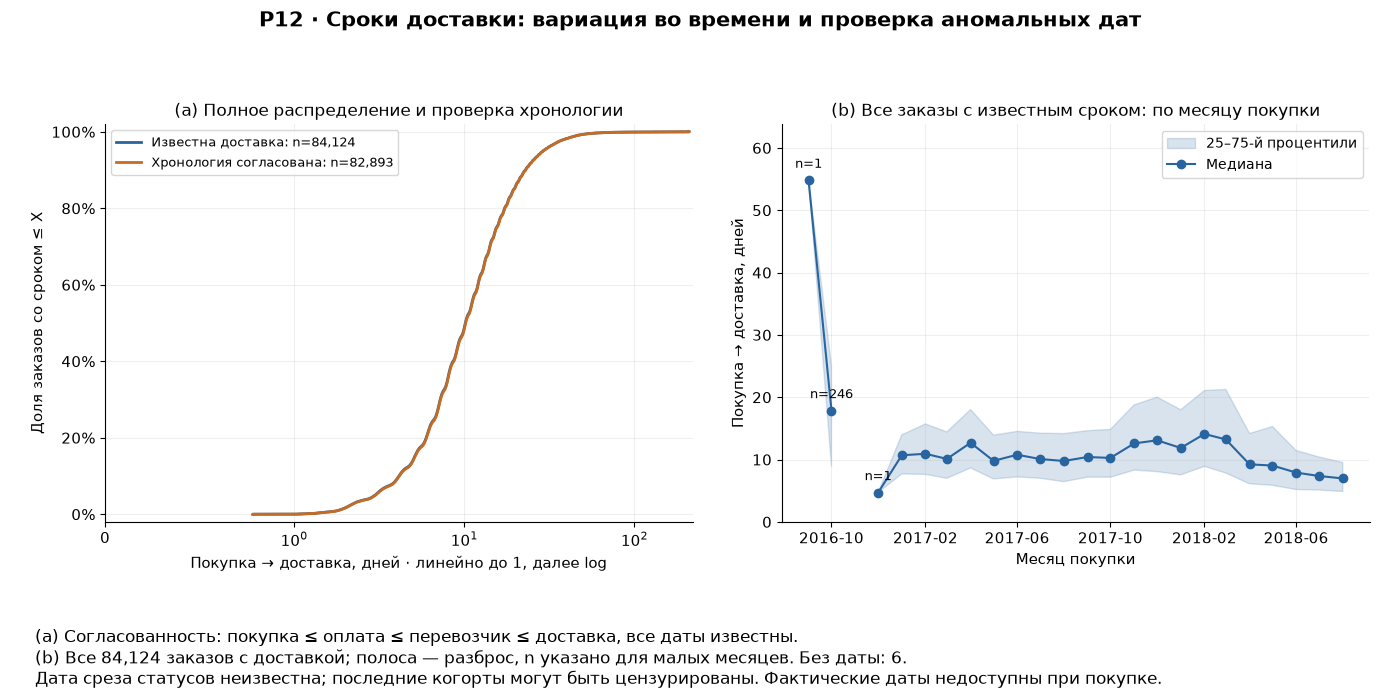

,n,"медиана, дни","p95, дни","опоздали, %"
Все с известной доставкой,84124.0,10.146,29.045,6.591
Согласованная хронология,82893.0,10.189,29.113,6.663


,заказов,известен срок,"медиана, дни","опоздали, %"
order_purchase_timestamp,,,,
2016-09-01,1,1,54.81,100.00
2016-10-01,246,246,17.85,0.41
2016-11-01,0,0,NaN,NaN
2016-12-01,1,1,4.69,0.00
2017-01-01,700,700,10.69,2.86
2017-02-01,1534,1534,10.93,3.00
2017-03-01,2322,2322,10.10,4.48
2017-04-01,2077,2077,12.69,6.64
2017-05-01,3192,3191,9.79,2.82


In [14]:
# P12
orders["delivery_days"] = (orders.order_delivered_customer_date - orders.order_purchase_timestamp).dt.total_seconds() / 86400
known_delivery = orders.order_delivered_customer_date.notna() & orders.order_estimated_delivery_date.notna()
orders["late"] = (orders.order_delivered_customer_date.dt.normalize() > orders.order_estimated_delivery_date.dt.normalize()).astype(float).where(known_delivery)
ordered_dates = orders[DATES].notna().all(axis=1)
ordered_dates &= orders.order_approved_at.ge(orders.order_purchase_timestamp)
ordered_dates &= orders.order_delivered_carrier_date.ge(orders.order_approved_at)
ordered_dates &= orders.order_delivered_customer_date.ge(orders.order_delivered_carrier_date)
delivery_month = orders.set_index("order_purchase_timestamp").resample("MS")
delivery_q = delivery_month.delivery_days.quantile([.25, .5, .75]).unstack()
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
ecdf(axes[0], orders.delivery_days, f"Известна доставка: n={orders.delivery_days.notna().sum():,}", BLUE)
ecdf(axes[0], orders.loc[ordered_dates, "delivery_days"], f"Хронология согласована: n={ordered_dates.sum():,}", ORANGE)
axes[0].set_xscale("symlog", linthresh=1)
axes[0].set_xlim(left=0)
axes[0].set_xlabel("Покупка → доставка, дней · линейно до 1, далее log")
axes[0].set_ylabel("Доля заказов со сроком ≤ X")
axes[0].set_title("(a) Полное распределение и проверка хронологии")
axes[0].legend(loc="upper left", fontsize=9)
axes[1].fill_between(delivery_q.index, delivery_q[.25], delivery_q[.75], color=BLUE, alpha=.18, label="25–75-й процентили")
axes[1].plot(delivery_q.index, delivery_q[.5], color=BLUE, marker="o", label="Медиана")
axes[1].set_ylim(bottom=0)
axes[1].set_title("(b) Все заказы с известным сроком: по месяцу покупки")
monthly_n = delivery_month.delivery_days.count()
for date, n in monthly_n.loc[monthly_n.between(1, 300)].items():
    axes[1].annotate(f"n={n}", (date, delivery_q.loc[date, .5]), xytext=(0, 9),
                     textcoords="offset points", ha="center", fontsize=9)
axes[1].set_ylim(0, delivery_q[.75].max() + 9)
axes[1].set_ylabel("Покупка → доставка, дней")
axes[1].set_xlabel("Месяц покупки")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[1].legend(fontsize=10)
axes[1].grid(alpha=.2)
finish(fig, "P12", "Сроки доставки: вариация во времени и проверка аномальных дат",
       "(a) Согласованность: покупка ≤ оплата ≤ перевозчик ≤ доставка, все даты известны.\n"
       f"(b) Все {orders.delivery_days.notna().sum():,} заказов с доставкой; полоса — разброс, n указано для малых месяцев. Без даты: {orders.delivery_days.isna().sum()}.\n"
       "Дата среза статусов неизвестна; последние когорты могут быть цензурированы. Фактические даты недоступны при покупке.")
delivery_summary = pd.DataFrame({
    "Все с известной доставкой": {"n": orders.delivery_days.notna().sum(), "медиана, дни": orders.delivery_days.median(),
                                  "p95, дни": orders.delivery_days.quantile(.95), "опоздали, %": orders.late.mean() * 100},
    "Согласованная хронология": {"n": ordered_dates.sum(), "медиана, дни": orders.loc[ordered_dates, "delivery_days"].median(),
                                "p95, дни": orders.loc[ordered_dates, "delivery_days"].quantile(.95),
                                "опоздали, %": orders.loc[ordered_dates, "late"].mean() * 100},
}).T
display(delivery_summary.round(3))
display(pd.DataFrame({"заказов": delivery_month.size(), "известен срок": delivery_month.delivery_days.count(),
                      "медиана, дни": delivery_month.delivery_days.median(), "опоздали, %": delivery_month.late.mean() * 100}).round(2))
findings.update(delivery_median_days=float(orders.delivery_days.median()), delivery_p95_days=float(orders.delivery_days.quantile(.95)),
                late_share=float(orders.late.mean()), late_orders=int(orders.late.sum()), late_denominator=int(known_delivery.sum()),
                clean_delivery_median_days=float(orders.loc[ordered_dates, "delivery_days"].median()))

- **Возвращение к качеству.** Проверим, не скрывает ли общая небольшая доля пропусков концентрацию по времени и регионам. Complete-case сравнение служит проверкой устойчивости выводов, а не правилом удаления строк.

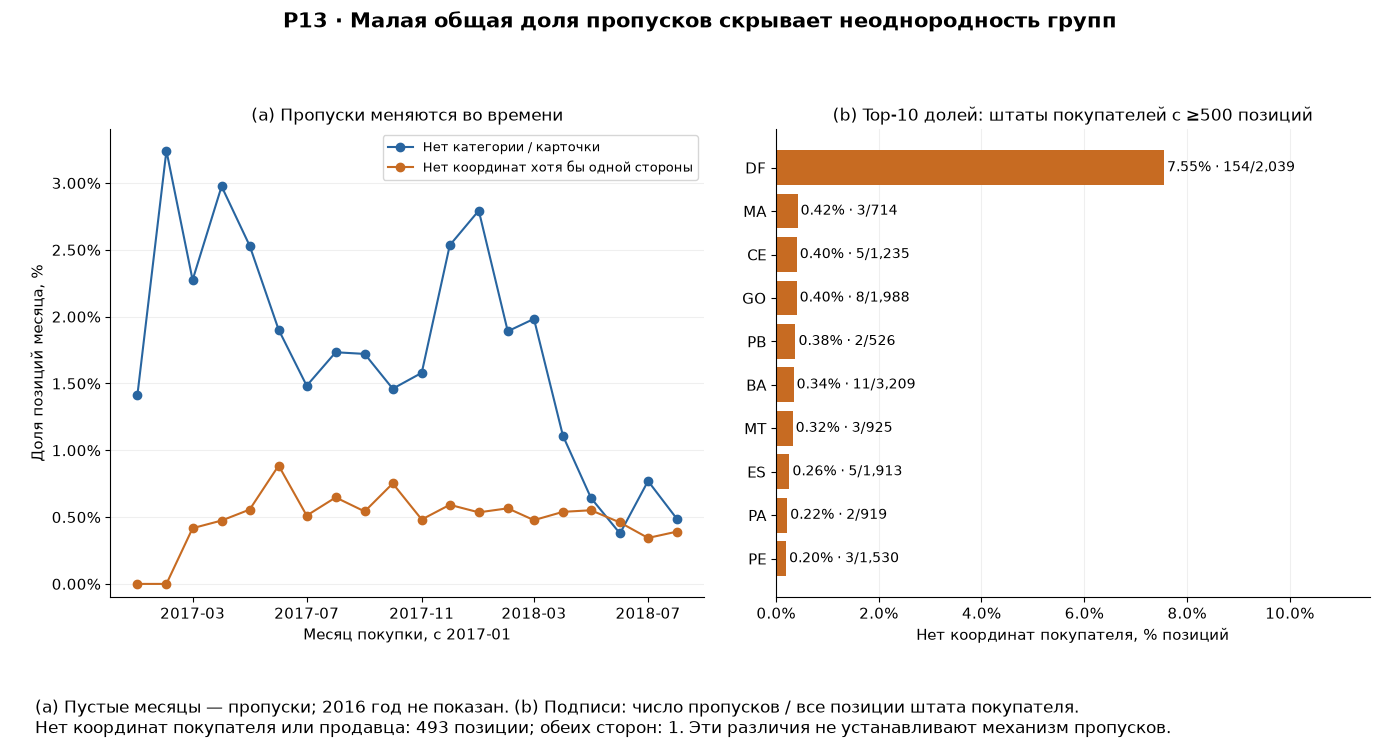

,выборка,позиции,медиана цены,"один заказ, %","товары в одной позиции, %","top-1% товаров: доля позиций, %"
0,Все строки,96068,69.9,97.157,57.117,21.185
1,Полные по исходным 35 полям,94022,69.9,97.195,57.083,21.121


In [15]:
# P13
# Проверяем исходные 35 полей, а не созданные аналитические столбцы.
original_cols = schema.index.tolist()
missing_by_month = df.assign(
    missing_card=df.product_category_name.isna(),
    missing_geo=~geo_known,
).set_index("order_purchase_timestamp").resample("MS")[["missing_card", "missing_geo"]].mean().mul(100)
stable = missing_by_month.loc["2017-01-01":]
state_missing = df.groupby("customer_state").agg(n=("order_id", "size"),
                                                  missing=("customer_geolocation_lat", lambda s: s.isna().sum()),
                                                  missing_geo=("customer_geolocation_lat", lambda s: s.isna().mean() * 100))
state_missing = state_missing.loc[state_missing.n.ge(500)].sort_values("missing_geo", ascending=False).head(10)
fig, axes = plt.subplots(1, 2, figsize=(14, 7.5))
axes[0].plot(stable.index, stable.missing_card, marker="o", color=BLUE, label="Нет категории / карточки")
axes[0].plot(stable.index, stable.missing_geo, marker="o", color=ORANGE, label="Нет координат хотя бы одной стороны")
axes[0].set_ylim(bottom=-.1)
axes[0].set_ylabel("Доля позиций месяца, %")
axes[0].set_xlabel("Месяц покупки, с 2017-01")
axes[0].set_title("(a) Пропуски меняются во времени")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[0].legend(fontsize=9)
percent_axis(axes[0], "y")
axes[1].barh(state_missing.index, state_missing.missing_geo, color=ORANGE)
axes[1].invert_yaxis()
for i, (_, row) in enumerate(state_missing.iterrows()):
    axes[1].text(row.missing_geo + .06, i, f"{row.missing_geo:.2f}% · {int(row['missing'])}/{int(row.n):,}", va="center", fontsize=10)
axes[1].set_xlim(0, state_missing.missing_geo.max() + 4)
axes[1].set_xlabel("Нет координат покупателя, % позиций")
axes[1].set_title("(b) Top-10 долей: штаты покупателей с ≥500 позиций")
percent_axis(axes[1])
finish(fig, "P13", "Малая общая доля пропусков скрывает неоднородность групп",
       "(a) Пустые месяцы — пропуски; 2016 год не показан. (b) Подписи: число пропусков / все позиции штата покупателя.\n"
       "Нет координат покупателя или продавца: 493 позиции; обеих сторон: 1. Эти различия не устанавливают механизм пропусков.")
complete = df.loc[df[original_cols].notna().all(axis=1)]
complete_checks = []
for label, frame in [("Все строки", df), ("Полные по исходным 35 полям", complete)]:
    hist = frame.drop_duplicates("order_id").groupby("customer_unique_id").size()
    pop = frame.product_id.value_counts()
    complete_checks.append({"выборка": label, "позиции": len(frame), "медиана цены": frame.price.median(),
                            "один заказ, %": hist.eq(1).mean() * 100, "товары в одной позиции, %": pop.eq(1).mean() * 100,
                            "top-1% товаров: доля позиций, %": pop.iloc[:math.ceil(len(pop) * .01)].sum() / len(frame) * 100})
display(pd.DataFrame(complete_checks).round(3))
findings["complete_case_sensitivity"] = complete_checks
findings["missingness_monthly_max"] = stable.max().to_dict()
findings["missingness_state"] = state_missing.to_dict("index")

- **Уточнение аномалий.** Пропуски DF распределены по 58 почтовым префиксам. Ни адресный штат, ни геосправочник автоматически не объявляются истиной. В конце проверяем повторы при одинаковом 90-дневном окне наблюдения.

In [16]:
# diagnostics
missing_df_geo = df.loc[df.customer_state.eq("DF") & df.customer_geolocation_lat.isna()]
df_geo_summary = pd.Series({"позиций DF без географии": len(missing_df_geo),
                            "разных почтовых префиксов": missing_df_geo.customer_zip_code_prefix.nunique(),
                            "наибольшее число позиций одного префикса": missing_df_geo.customer_zip_code_prefix.value_counts().max()})
display(df_geo_summary)
seller_mismatch = df.loc[df.seller_geolocation_state.notna() & df.seller_state.ne(df.seller_geolocation_state)]
display(seller_mismatch.groupby(["seller_state", "seller_geolocation_state"]).size().rename("позиций"))
display(df.loc[geo_known & ~geo_valid, ["customer_zip_code_prefix", "customer_state", *geo_cols]].drop_duplicates())
categorical_columns = [c for c in original_cols if c not in [*KEY, "customer_id", "customer_unique_id", "product_id", *DATES, *NUMERIC, *geo_cols]]
categorical_width = df[categorical_columns].nunique().rename("категорий")
display(categorical_width)
findings["df_missing_geo_prefixes"] = int(missing_df_geo.customer_zip_code_prefix.nunique())
findings["categorical_width_observed"] = int(categorical_width.sum())
# Проверка полноценного 90-дневного окна: последняя покупка набора задаёт
# только наблюдаемую границу, а не гарантированное полное покрытие платформы.
display(pd.DataFrame([{"пользователей с ≥90 днями до конца окна": len(repeat90),
                       "повторили заказ за 90 дней": int(repeat90.sum()),
                       "доля, %": repeat90.mean() * 100}]))

позиций DF без географии                    154
разных почтовых префиксов                    58
наибольшее число позиций одного префикса     16
dtype: int64

seller_state  seller_geolocation_state
PA            PR                            8
RN            RJ                            2
SP            BA                            3
              DF                            1
              MG                           66
              PR                           97
              RJ                          122
              RS                            6
              SC                          140
Name: позиций, dtype: int64

,customer_zip_code_prefix,customer_state,customer_geolocation_lat,customer_geolocation_lng,seller_geolocation_lat,seller_geolocation_lng
6914,46560,BA,13.001420,-23.583939,-23.652443,-46.755492
32161,68275,PA,41.146203,-8.577855,-21.258652,-47.813946
86216,83252,PR,42.184003,-8.723762,-26.231306,-49.412569


order_status                      1
customer_zip_code_prefix      14462
customer_city                  3924
customer_state                   27
customer_geolocation_city      3869
customer_geolocation_state       27
seller_zip_code_prefix         2130
seller_city                     588
seller_state                     22
seller_geolocation_city         538
seller_geolocation_state         21
product_category_name            73
Name: категорий, dtype: int64

,пользователей с ≥90 днями до конца окна,повторили заказ за 90 дней,"доля, %"
0,65682,1423,2.166499


- **Оценка рекомендаций.** Синтетические истории оправданы как учебный эксперимент, но их метрики не доказывают качество на реальных пользователях. Для реальных данных нужны явно определённые cold-start-правила и отдельный отчёт о покрытии; товары без обучающей истории сохраняются в ground truth.
- **Отбор.** Фильтр по единственному продавцу во всей истории и конечному статусу использует последующую информацию. Даже хронологическое разбиение текущего CSV остаётся условным на ретроспективном отборе. Суммы частичных корзин не следует называть полным чеком.
- **Предобработка.** Идентификаторы — ключи, индексы — категории; константный `order_status` не различает строки. Полное one-hot кодирование городов и префиксов создаёт десятки тысяч координат и дублирует географические сигналы. Проверить вклад групп в расстояние; обучать imputer/scaler/encoder только на train.
- **Числа.** Сравнить baseline со способами уменьшения влияния хвостов, например `log1p` для неотрицательных величин. Учесть взаимосвязь массы и объёма. Низкая общая корреляция числа фото не доказывает бесполезность признака. Нули массы и аномальные координаты требуют явного правила, а не общего удаления строк.
- **Доступность во времени.** Фактические подтверждение, перевозка и доставка недоступны при оформлении покупки. Производные сроки допустимы для этого EDA; в рекомендательной модели их применение зависит от явно заданного момента прогноза. Исторические версии карточек отсутствуют.
- **Границы вывода.** Неизвестны дата среза статусов, истинная доступность каталога и причины пропусков; возможны цензурирование последних когорт и остаточное смешение факторов. Неоднородность геопропусков требует контроля по регионам. Подгрупповые проверки устойчивости не заменяют причинного исследования.


In [17]:
assert plot_ids == ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13']
assert findings['rows'] == 96068 and findings['columns'] == 35
assert findings['orders'] == 84130 and findings['products'] == 30991
assert findings['repeat_users'] == 2318 and findings['partial_orders'] == 328
assert findings['late_orders'] == 5545
assert findings['df_missing_geo_prefixes'] == 58
summary = pd.Series({
    'Пользователи с одним заказом, %': findings['single_order_share'] * 100,
    'Товары в одной позиции, %': findings['singleton_product_share'] * 100,
    'Плотность user–item, %': findings['matrix_density'] * 100,
    'Медиана срока доставки, дней': findings['delivery_median_days'],
    'Поздние доставки, %': findings['late_share'] * 100,
    'One-hot: сумма наблюдаемых категорий без ID': findings['categorical_width_observed'],
})
display(summary.round(4))
print('Проверены расчёты и последовательность всех 13 рисунков.')

Пользователи с одним заказом, %                   97.1573
Товары в одной позиции, %                         57.1166
Плотность user–item, %                             0.0034
Медиана срока доставки, дней                      10.1462
Поздние доставки, %                                6.5915
One-hot: сумма наблюдаемых категорий без ID    25682.0000
dtype: float64

Проверены расчёты и последовательность всех 13 рисунков.
